In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/bug_dataset.csv")
df.head()


,project,bug_id,python_version,buggy_commit_id,fixed_commit_id,test_file,patch,pythonpath,modified_files,num_files_changed,...,declared_functions_in_patch,number_of_declared_classes_in_patch,number_of_declared_functions_in_patch,exception_types,num_exception_types,modified_modules,num_modified_modules,bug_category,label_reason,confidence
0,keras,32,3.7.3,a3d160b9467c99cbb27f9aa0382c759f45c8ee66,709f791af201caaab4aa180bda259989087cfe47,tests/keras/test_callbacks.py,diff --git a/keras/callbacks.py b/keras/callba...,NaN,['keras/callbacks.py'],1,...,"['__init__', 'in_cooldown']",5,2,['ValueError'],1,['keras'],1,API and Configuration,The patch renames a constructor keyword argume...,Medium
1,keras,35,3.7.3,06eaeebecfb73c23bfd531013ca172ee3bf5069c,738819de0b7e6bc45abed8d0640f02b81c6ac4e9,tests/keras/preprocessing/image_test.py,diff --git a/keras/preprocessing/image.py b/ke...,NaN,['keras/preprocessing/image.py'],1,...,[],3,0,['ValueError'],1,['keras/preprocessing'],1,API and Configuration,The patch relocates the user-supplied preproce...,Medium
2,keras,34,3.7.3,7ef5244a2f1f7f7b76e3c804b82cbb20cdf4d139,4b74fc5418944c9f449eb88ed4b40ada280fa5ca,tests/test_multiprocessing.py,diff --git a/keras/engine/training.py b/keras/...,NaN,"['keras/engine/training.py', 'keras/utils/data...",2,...,['__iter__'],5,1,[],0,"['keras/engine', 'keras/utils']",2,Collections and Indexing,The patch adds an __iter__ implementation and ...,Medium
3,keras,33,3.7.3,1c9a49781da2101507db23e2014e4e5d16bd2e52,70ad0d6e4a569701ef106058397ad0540ec08340,tests/keras/preprocessing/text_test.py,diff --git a/keras/preprocessing/text.py b/ker...,NaN,['keras/preprocessing/text.py'],1,...,['text_to_word_sequence'],0,1,[],0,['keras/preprocessing'],1,Type Handling,The patch corrects str/unicode assumptions and...,Medium
4,keras,20,3.7.3,76da5f0a21ca98e4bf6706e182fb825243e76204,6dd087ab73b09e449144ff17450cc14f981b9ac2,tests/keras/layers/convolutional_test.py,diff --git a/keras/backend/cntk_backend.py b/k...,NaN,"['keras/backend/cntk_backend.py', 'keras/backe...",5,...,"['in_top_k', 'conv2d_transpose', 'conv2d_trans...",5,22,['ValueError'],1,"['keras/backend', 'keras/layers', 'keras/utils']",3,API and Configuration,The patch threads a missing dilation_rate para...,Medium


### Since BugsInPy does not provide semantic bug-type annotations, a taxonomy of nine bug categories was developed and  applied to all bug patches. Each bug was assigned a single primary category based on the underlying defect corrected by the patch. Exception types were treated as supporting evidence rather than labels. Ambiguous cases were explicitly identified through confidence ratings, enabling low-confidence annotations to be excluded from model training.

## Class distribution

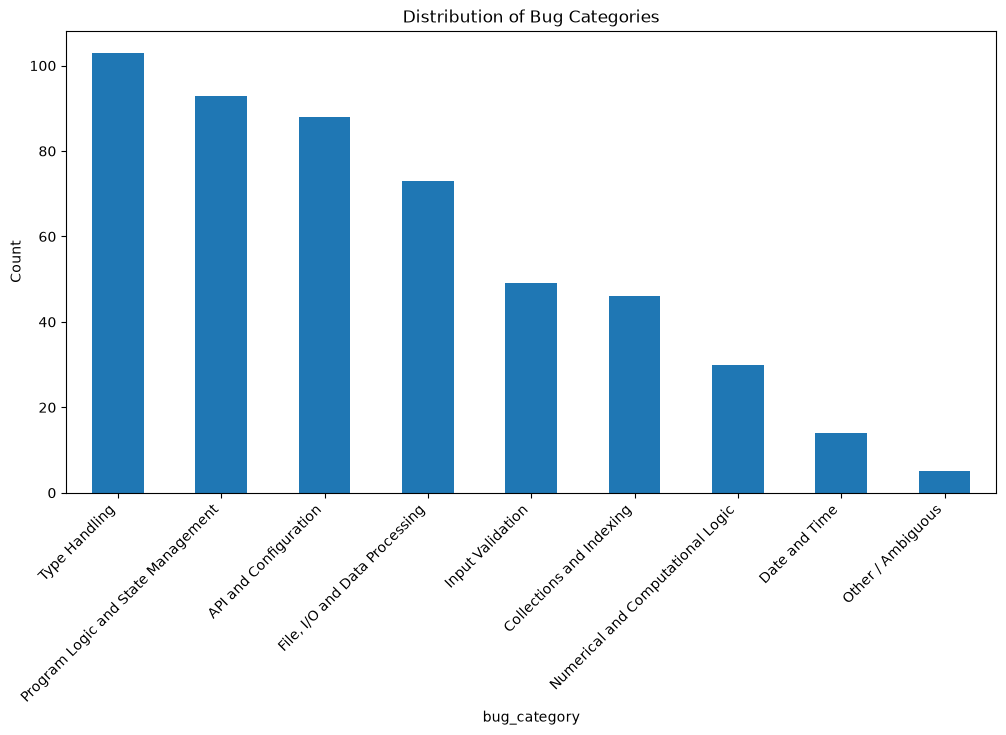

In [10]:
df["bug_category"].value_counts().plot(kind="bar",figsize=(12,6))
plt.title("Distribution of Bug Categories")
plt.ylabel("Count")
plt.xticks(rotation=45,ha="right")
plt.show()

In [14]:
counts = df["bug_category"].value_counts()
counts

bug_category
Type Handling                         103
Program Logic and State Management     93
API and Configuration                  88
File, I/O and Data Processing          73
Input Validation                       49
Collections and Indexing               46
Numerical and Computational Logic      30
Date and Time                          14
Other / Ambiguous                       5
Name: count, dtype: int64

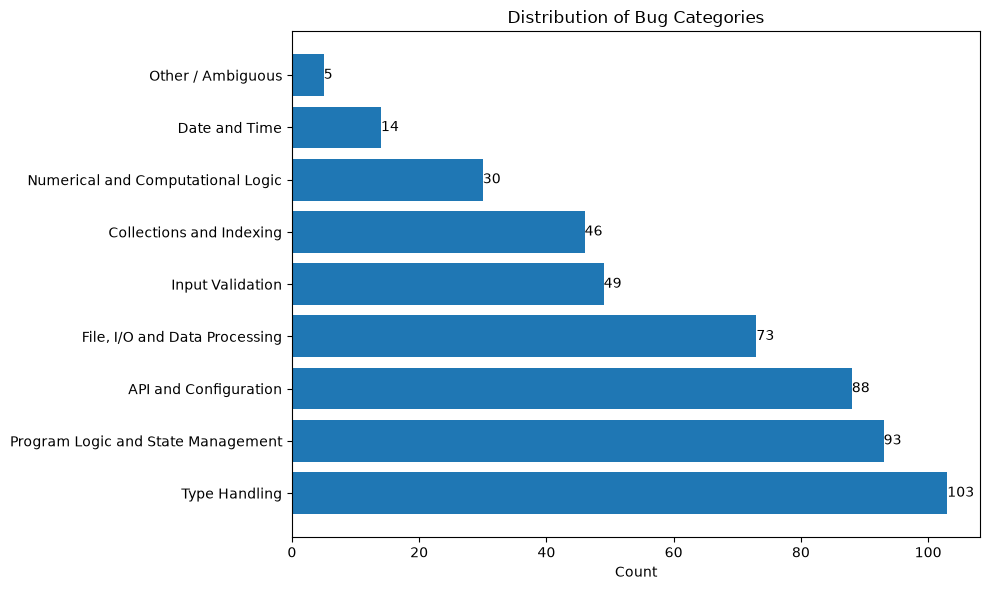

In [15]:
plt.figure(figsize=(10,6))
bars = plt.barh(counts.index,counts.values)

plt.title("Distribution of Bug Categories")
plt.xlabel("Count")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

## Confidence distribution

<Axes: xlabel='confidence', ylabel='count'>

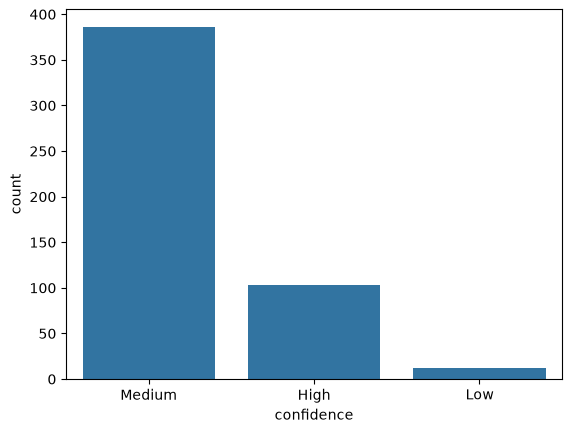

In [17]:
sns.countplot(data=df,x="confidence")

Most annotations were assigned medium confidence, reflecting conservative manual labeling. Low-confidence cases represent ambiguous patches and may optionally be excluded during model training.

##  Project × Bug Category Heatmap

<Axes: xlabel='bug_category', ylabel='project'>

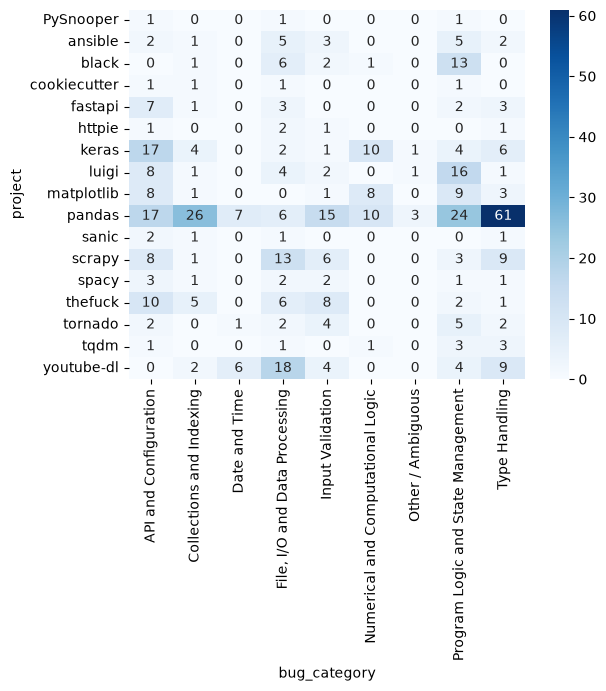

In [22]:
cross = pd.crosstab(df["project"],df["bug_category"])
sns.heatmap(data=cross,cmap = "Blues",annot = True,)

* Bug categories are not uniformly distributed across repositories. Different projects exhibit distinct bug profiles, suggesting that repositories tend to experience different types of defects depending on their functionality and architecture.
* Type Handling is the most prevalent category across the dataset and appears in nearly every repository, indicating that type-related defects are common regardless of project domain.
* Program Logic and State Management is also widespread across repositories, suggesting that incorrect control flow, state transitions, and algorithmic logic are frequent sources of software defects.

Repository-specific patterns

* Pandas exhibits the greatest diversity of bug categories and contains the largest number of bugs overall. It has particularly high frequencies of Type Handling, Collections and Indexing, and Program Logic and State Management bugs, reflecting the complexity of its data structures and internal APIs.
* YouTube-DL contains a comparatively large number of File, I/O and Data Processing bugs, which is probably because its extensive interaction with external web content and parsing logic.
* Keras shows a noticeable concentration of API and Configuration and Numerical and Computational Logic bugs, consistent with its machine learning APIs and numerical computation workflows.
* Matplotlib contains relatively more Numerical and Computational Logic bugs than most repositories, likely reflecting its heavy reliance on graphical computations and rendering logic.

Rare categories

* Date and Time bugs appear in only a small number of repositories and are relatively uncommon throughout the dataset.
* Other / Ambiguous occurs only a few times, indicating that the proposed taxonomy successfully captures the vast majority of bug fixes without requiring a large miscellaneous category.

<Axes: xlabel='bug_category', ylabel='project'>

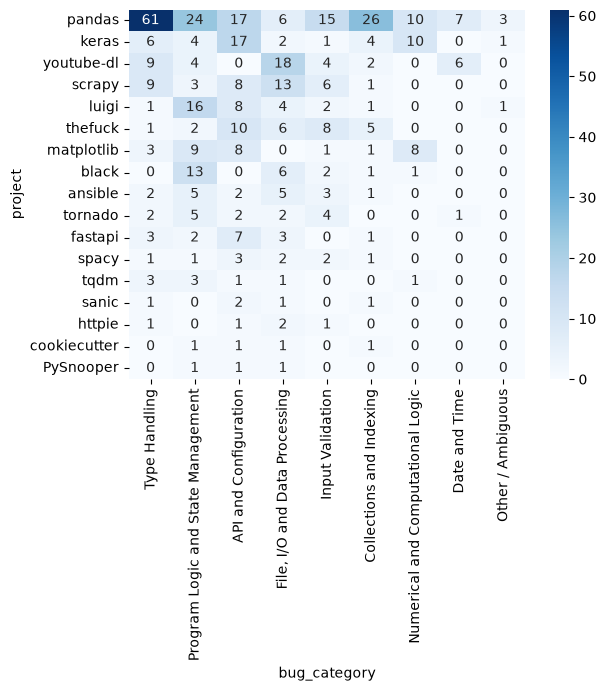

In [23]:
project_order = df["project"].value_counts().index
category_order = df["bug_category"].value_counts().index

cross = pd.crosstab(df["project"],df["bug_category"])
cross = cross.loc[project_order,category_order]
sns.heatmap(cross, cmap = "Blues" ,annot =True, fmt = "d")

## Patch Length Distribution by Bug Category

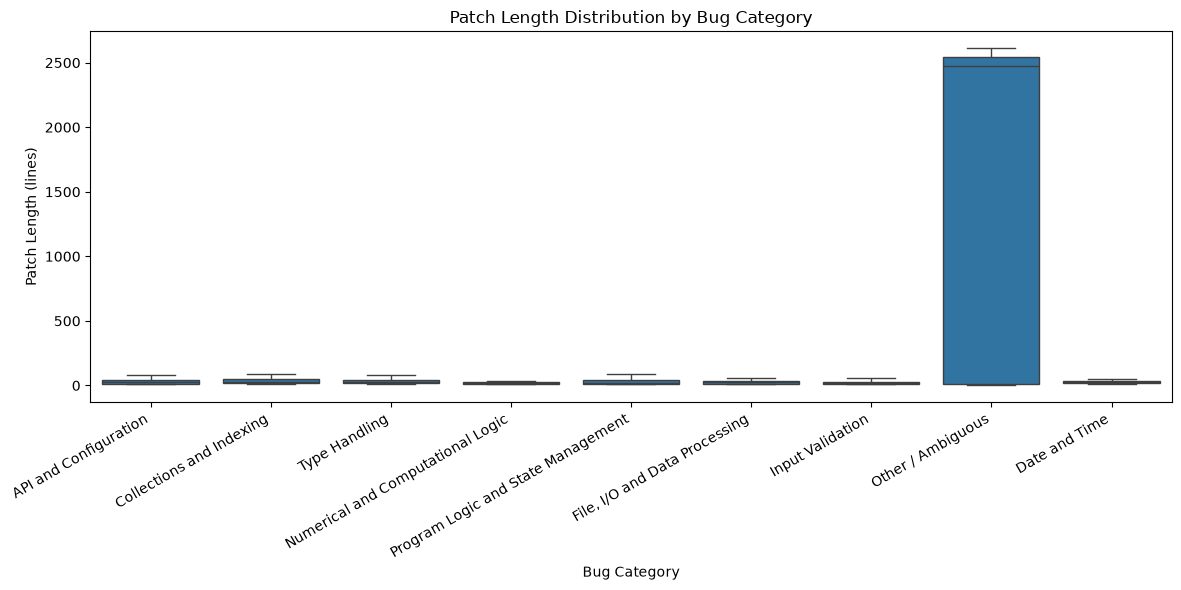

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(df,x="bug_category",y="patch_length",showfliers = False)
plt.title("Patch Length Distribution by Bug Category")
plt.xlabel("Bug Category")
plt.ylabel("Patch Length (lines)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


The “Other / Ambiguous” category contains 3 corrupted Pandas patches (~2500 lines) 

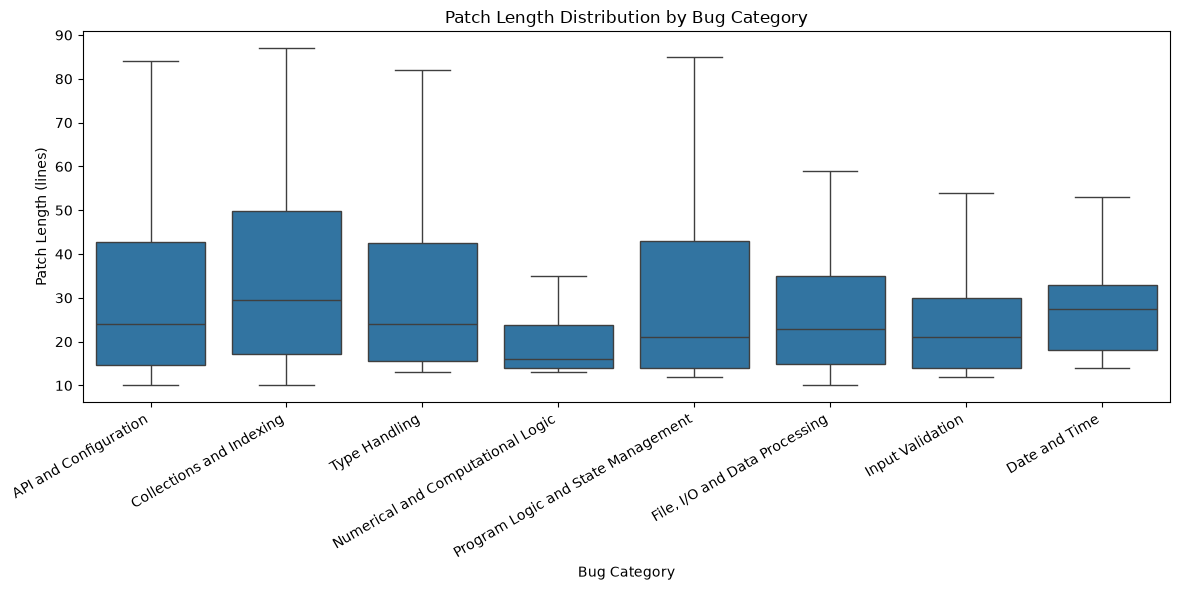

In [28]:
plot_df = df[df["bug_category"] != "Other / Ambiguous"]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x="bug_category",
    y="patch_length",
    showfliers = False
)

plt.title("Patch Length Distribution by Bug Category")
plt.xlabel("Bug Category")
plt.ylabel("Patch Length (lines)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

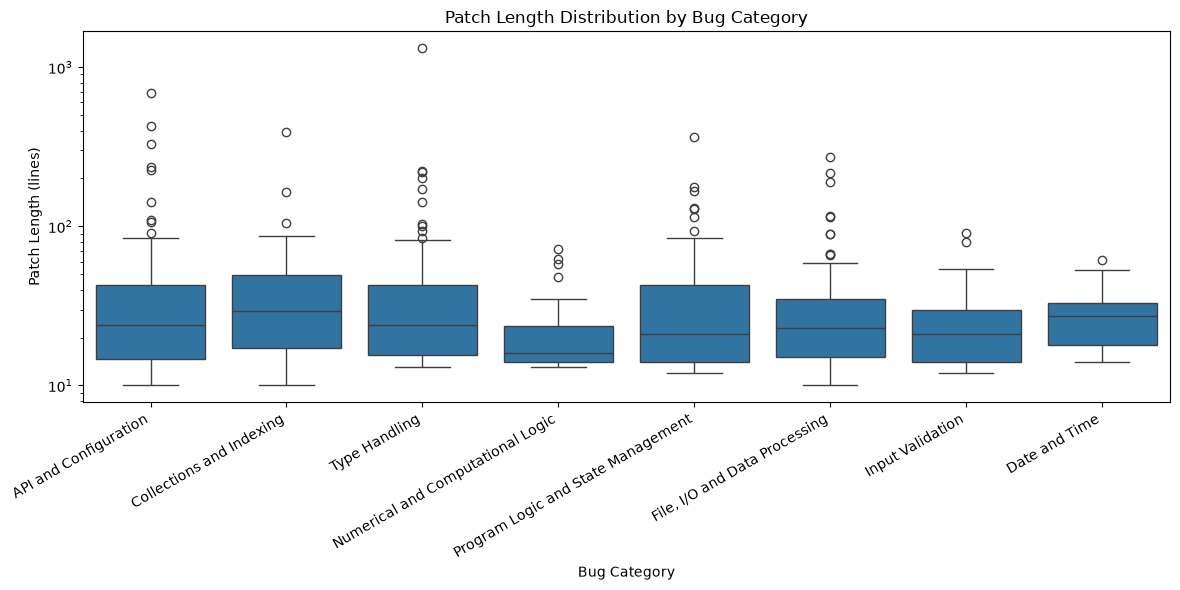

In [27]:
plot_df = df[df["bug_category"] != "Other / Ambiguous"]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x="bug_category",
    y="patch_length",
)

plt.title("Patch Length Distribution by Bug Category")
plt.xlabel("Bug Category")
plt.ylabel("Patch Length (lines)")
plt.xticks(rotation=30, ha="right")
plt.yscale("log")
plt.tight_layout()
plt.show()

* The Other / Ambiguous category was excluded from this analysis because it contains three corrupted Pandas patches exceeding 2,500 lines, which disproportionately influence the visualization without providing meaningful insight into patch size distributions.
* Across all bug categories, the median patch length is relatively small, indicating that most bug fixes involve localized code modifications rather than extensive refactoring.
* Collections and Indexing exhibits the highest median patch length and one of the widest interquartile ranges, suggesting that fixes involving collection operations and indexing tend to require relatively larger code changes than other categories.
* Program Logic and State Management, Type Handling, and API and Configuration display comparatively wide distributions, indicating substantial variability in the size of patches required to resolve these defects.
* Numerical and Computational Logic has the smallest median patch length and the narrowest interquartile range, suggesting that computational defects are generally addressed through more focused algorithmic modifications.
* Input Validation and File, I/O and Data Processing exhibit moderate patch lengths with less variability than logic-related defects, indicating that these bugs are typically resolved through targeted changes.
* The presence of longer upper whiskers in several categories indicates that, while most fixes are relatively small, a subset of bugs requires considerably larger code modifications. This reflects variability in implementation complexity within the same semantic bug category.

## Lines Changed by Bug Category
Unlike patch length (which includes context lines and metadata), lines changed measures the actual amount of code modified.

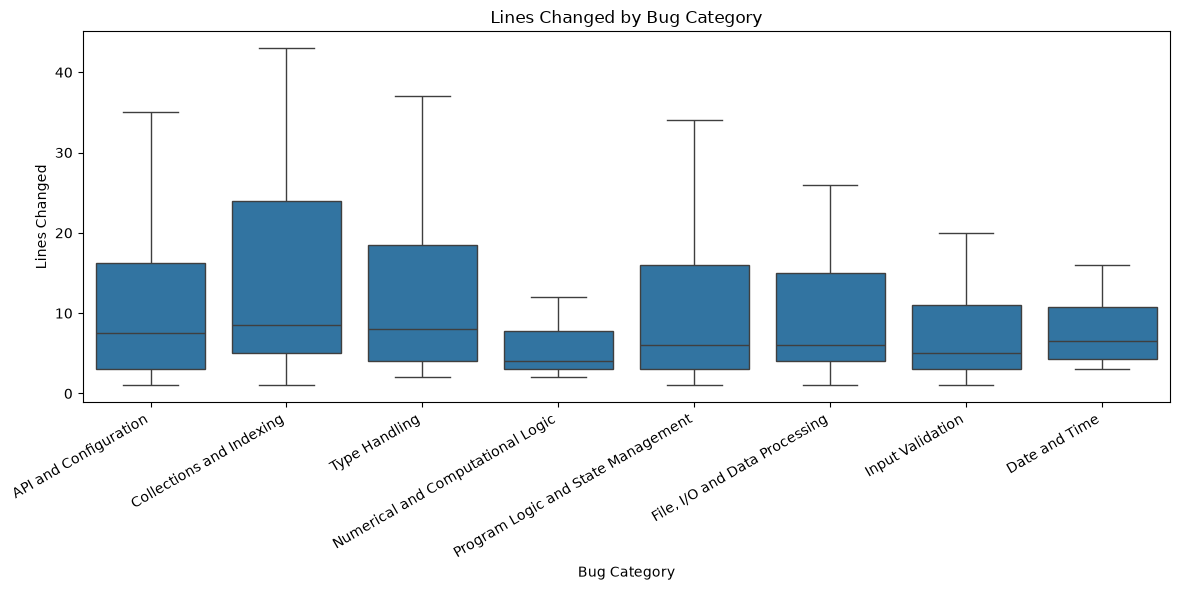

In [36]:
plt.figure(figsize=(12,6))
plot_df["lines_changed"]=(plot_df["lines_added"]+plot_df["lines_removed"])
sns.boxplot(plot_df,x="bug_category",y="lines_changed",showfliers=False)
plt.title("Lines Changed by Bug Category")
plt.xlabel("Bug Category")
plt.ylabel("Lines Changed")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

this measures actual code churn rather than total patch size unlike previous analysis.this metric excludes contextual lines in the Git diff and therefore provides a more direct measure of the amount of code changed during a bug fix.

* Across all bug categories, the median number of lines changed is relatively small, indicating that most bug fixes require modifications to only a limited number of lines of code.
* Collections and Indexing exhibits the highest median number of lines changed together with one of the widest interquartile ranges, suggesting that collection-related defects often require more extensive code modifications.
* Type Handling, Program Logic and State Management, and API and Configuration also display relatively large variability in code churn, indicating that fixes within these categories range from simple localized changes to substantially larger modifications.
* Numerical and Computational Logic has the smallest median number of lines changed and the narrowest distribution, suggesting that computational defects are typically resolved through focused algorithmic corrections.
* Input Validation and Date and Time generally involve fewer modified lines and exhibit comparatively smaller variability, indicating that these bug types are often corrected through localized code changes.

## Feature Importance Screening (Feature vs. Target)

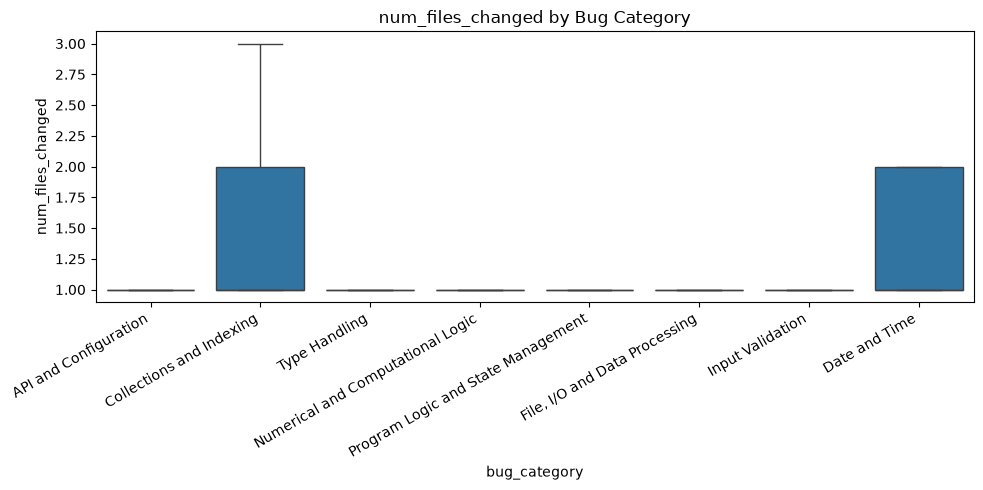

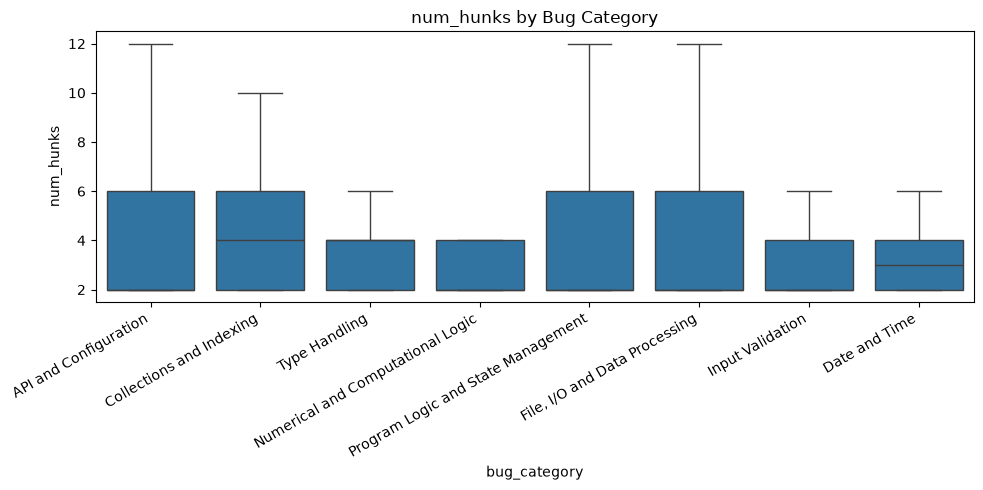

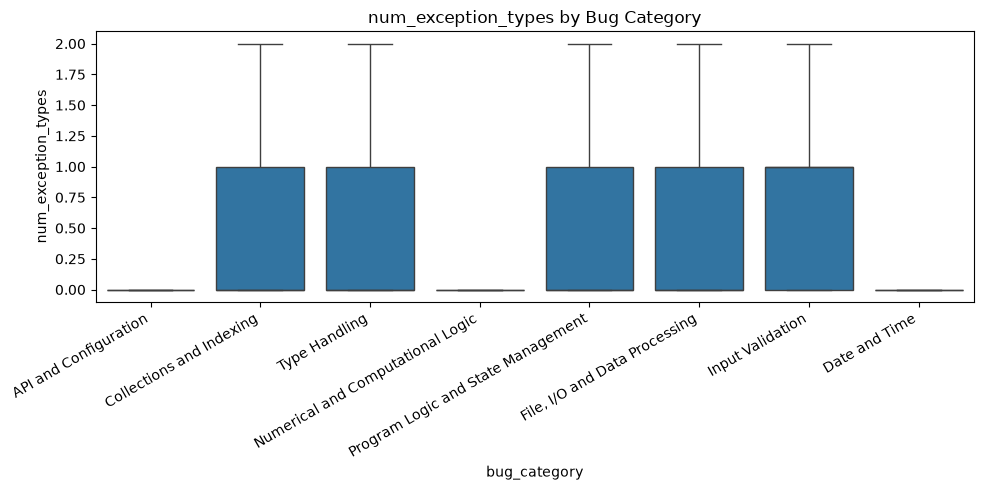

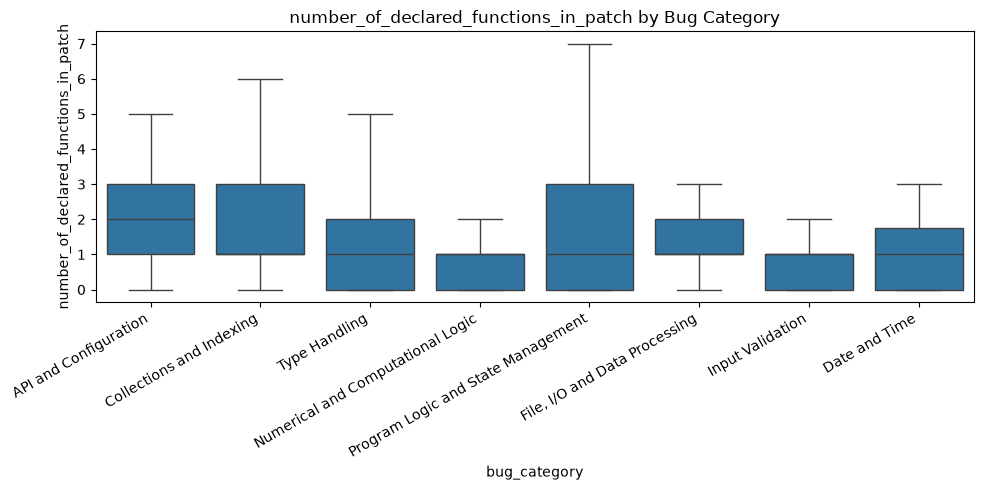

In [37]:
features = [
    "num_files_changed",
    "num_hunks",
    "num_exception_types",
    "number_of_declared_functions_in_patch"
]

for feature in features:
    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=plot_df,
        x="bug_category",
        y=feature,
        showfliers=False
    )

    plt.xticks(rotation=30, ha="right")
    plt.title(f"{feature} by Bug Category")
    plt.tight_layout()
    plt.show()

1. Number of Files Changed

* The majority of bug fixes across all categories modify only a single source file, indicating that most defects are localized.
* Collections and Indexing and Date and Time exhibit greater variability, with some fixes involving modifications across multiple files.
* The limited variation across most categories suggests that num_files_changed alone has relatively low discriminative power, although it may provide complementary information when combined with other structural features.

2. Number of Hunks

* Most bug categories require between 2 and 6 contiguous code modifications (hunks), indicating that many fixes involve changes across multiple localized regions of a file.
* Program Logic and State Management and File, I/O and Data Processing exhibit relatively larger variability in the number of hunks, suggesting that these defects often require modifications in multiple sections of the codebase.
* Considerable overlap exists among the distributions, indicating that num_hunks is unlikely to distinguish bug categories independently, but may contribute useful structural information when combined with other features.

3. Number of Exception Types

This one is actually quite interesting.

* Most bug fixes involve zero or one exception type, with only a small number referencing multiple exceptions.
* Several bug categories, including Type Handling, Input Validation, and File, I/O and Data Processing, contain similar distributions of exception counts.
* The substantial overlap across categories suggests that the number of exception types is not strongly associated with a particular bug category.
* While the count of exception types provides limited discriminative information, the specific exception types themselves may still be valuable predictive features during model training.

Number of Declared Functions in Patch

* Most bug fixes modify between zero and three function declarations, indicating that the majority of patches affect only a small number of functions.
* API and Configuration and Collections and Indexing exhibit slightly higher variability in the number of declared functions appearing within patches.
* Numerical and Computational Logic and Input Validation generally involve fewer function declarations, reflecting more localized modifications.
* Although differences exist among categories, the distributions overlap substantially, suggesting that this feature alone is insufficient for classification but may contribute useful contextual information when combined with other engineered features.

## Exception Type × Bug Category heatmap

In [42]:
import ast

df["exception_types"] = df["exception_types"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
exception_df = (
    df[df["bug_category"] != "Other / Ambiguous"]
    .explode("exception_types")
    .reset_index(drop=True)
)

exception_df = exception_df[
    exception_df["exception_types"].notna()
    & (exception_df["exception_types"] != "")
]

In [43]:
top_exceptions = (
    exception_df["exception_types"]
    .value_counts()
    .head(10)
    .index
)

exception_df = exception_df[
    exception_df["exception_types"].isin(top_exceptions)
]

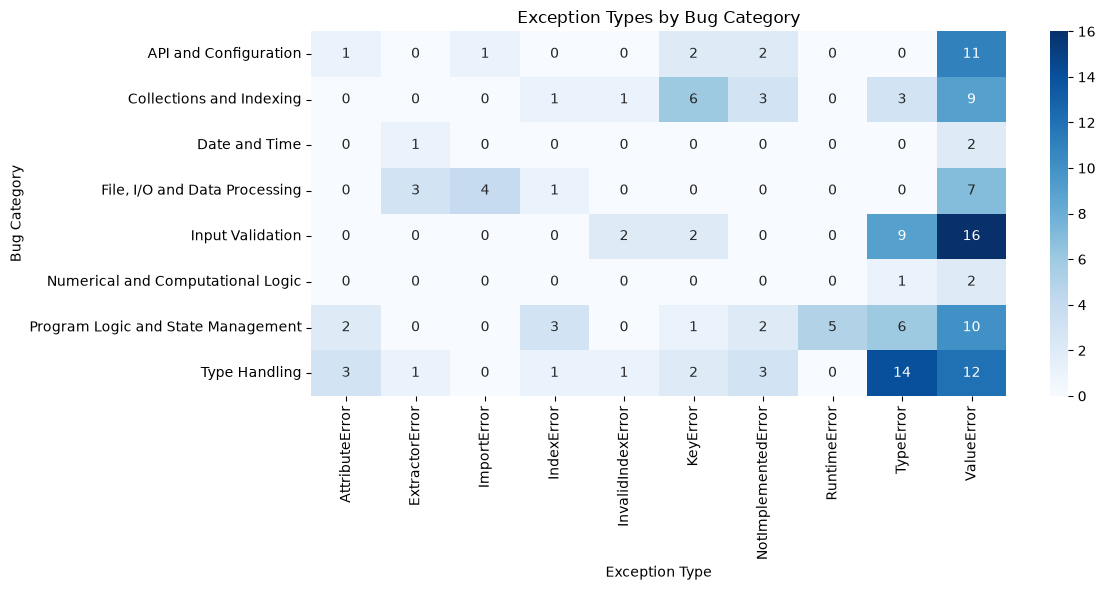

In [44]:
cross = pd.crosstab(
    exception_df["bug_category"],
    exception_df["exception_types"]
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    cross,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Exception Types by Bug Category")
plt.xlabel("Exception Type")
plt.ylabel("Bug Category")
plt.tight_layout()
plt.show()

Most bug patches do not explicitly mention an exception type, but analysing those that do:
* ValueError is the most frequently occurring exception type across the dataset and appears in multiple bug categories, particularly Input Validation, Type Handling, API and Configuration, and Program Logic and State Management.
* TypeError is most strongly associated with Type Handling, supporting the intuition that type-related defects commonly manifest as type mismatches at runtime.
* KeyError occurs predominantly within Collections and Indexing, indicating a strong semantic relationship between dictionary or indexing operations and this exception type.
* Several exception types, including AttributeError, ImportError, and NotImplementedError, occur infrequently and are distributed across multiple bug categories, suggesting that they provide limited discriminative information individually.


## Modified Modules × Bug Category

In [52]:
module_df = df.explode("modified_modules").reset_index(drop=True)

top_modules = (
    module_df["modified_modules"]
    .value_counts()
    .head(15)
    .index
)

module_df = module_df[
    module_df["modified_modules"].isin(top_modules)
].reset_index(drop=True)

cross = pd.crosstab(
    module_df["bug_category"],
    module_df["modified_modules"]
)

cross

modified_modules,.,keras,keras/engine,lib/matplotlib,luigi,pandas/core,pandas/core/arrays,pandas/core/groupby,pandas/core/indexes,pandas/core/internals,pandas/core/reshape,scrapy,thefuck/rules,tornado,youtube_dl
bug_category,,,,,,,,,,,,,,,
API and Configuration,0,6,3,3,7,1,2,3,6,1,1,3,4,2,0
Collections and Indexing,1,0,1,1,1,12,1,4,5,2,5,0,3,0,1
Date and Time,0,0,0,0,0,1,3,0,0,0,0,0,0,1,6
"File, I/O and Data Processing",5,1,1,0,2,0,0,0,0,1,0,2,4,2,17
Input Validation,3,0,1,1,0,7,1,1,3,1,1,0,8,4,3
Numerical and Computational Logic,0,2,1,5,0,3,3,0,1,1,0,0,0,0,0
Other / Ambiguous,0,0,0,0,1,0,3,0,0,0,0,0,0,0,0
Program Logic and State Management,13,0,3,6,13,4,0,2,6,3,3,2,2,5,4
Type Handling,0,1,2,2,1,12,13,5,11,4,8,4,1,2,9


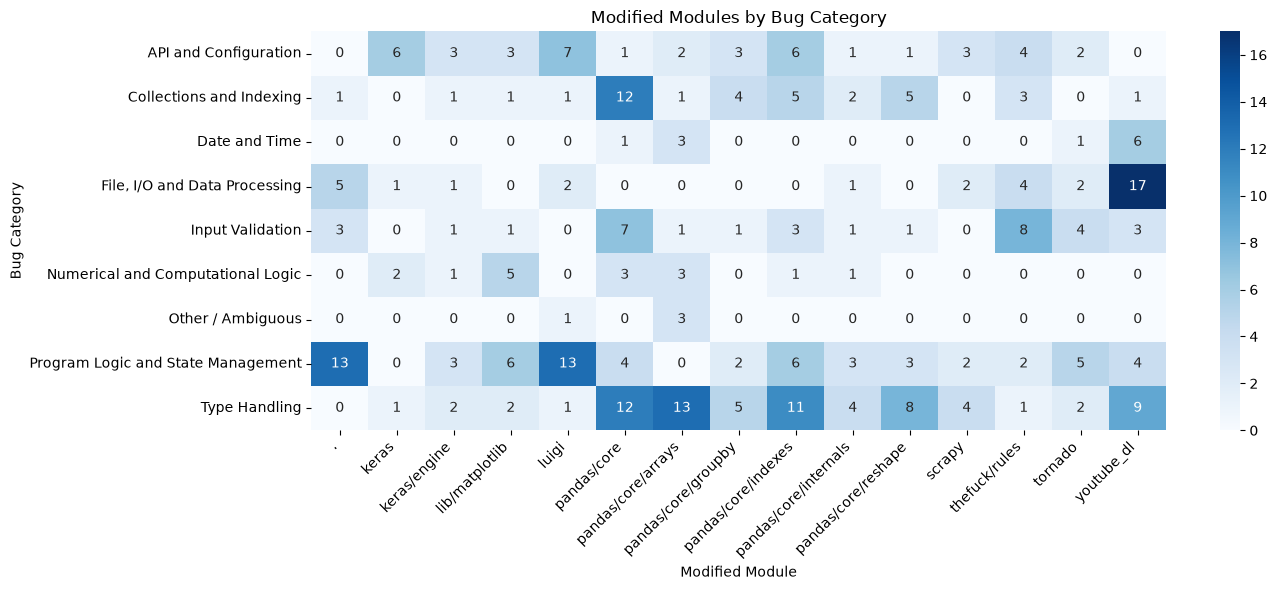

In [53]:
plt.figure(figsize=(14,6))

sns.heatmap(
    cross,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Modified Modules by Bug Category")
plt.xlabel("Modified Module")
plt.ylabel("Bug Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* The distribution of modified modules differs noticeably across bug categories, indicating that defects are not uniformly distributed across repository components.
* Several modules show stronger associations with particular bug categories. For example, pandas/core/arrays and pandas/core/indexes are frequently associated with Type Handling, while pandas/core appears more prominently in Collections and Indexing.
* Repository-specific modules, such as keras, youtube_dl, and luigi, exhibit distinct bug-category distributions, suggesting that different software systems experience different types of defects depending on their architecture and functionality.
* Some modules contribute to multiple bug categories, indicating that the same component can contain a variety of defect types rather than being associated with a single class of bug.

In [54]:
ml_df = df[
    (df["bug_category"] != "Other / Ambiguous") &
    (df["confidence"] != "Low")
].copy()

In [55]:
ml_df.to_csv("../data/processed/bug_dataset_ml.csv", index=False)